In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
DATASET_PATH = r'C:\Users\Lenovo\Desktop\color'
MODEL_PATH   = 'mobilenet_plantvillage.pth'
IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_CLASSES  = 38
SEED         = 42
device       = torch.device("cpu")

In [3]:
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
 
full_dataset = datasets.ImageFolder(DATASET_PATH)
class_names  = full_dataset.classes
 
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size
 
_, _, test_data = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)
test_data.dataset.transform = val_transforms
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
model = models.mobilenet_v2(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print("Model loaded successfully ✅")

Model loaded successfully ✅


In [5]:
all_preds, all_labels = [], []
 
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [6]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.89      0.93        91
                                 Apple___Black_rot       0.97      1.00      0.98        87
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        37
                                   Apple___healthy       0.99      0.96      0.98       270
                               Blueberry___healthy       1.00      0.99      1.00       198
          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.97       176
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       125
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.73      0.82      0.77        71
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       168
               Corn_(maize)___Northern_Leaf_Blight     

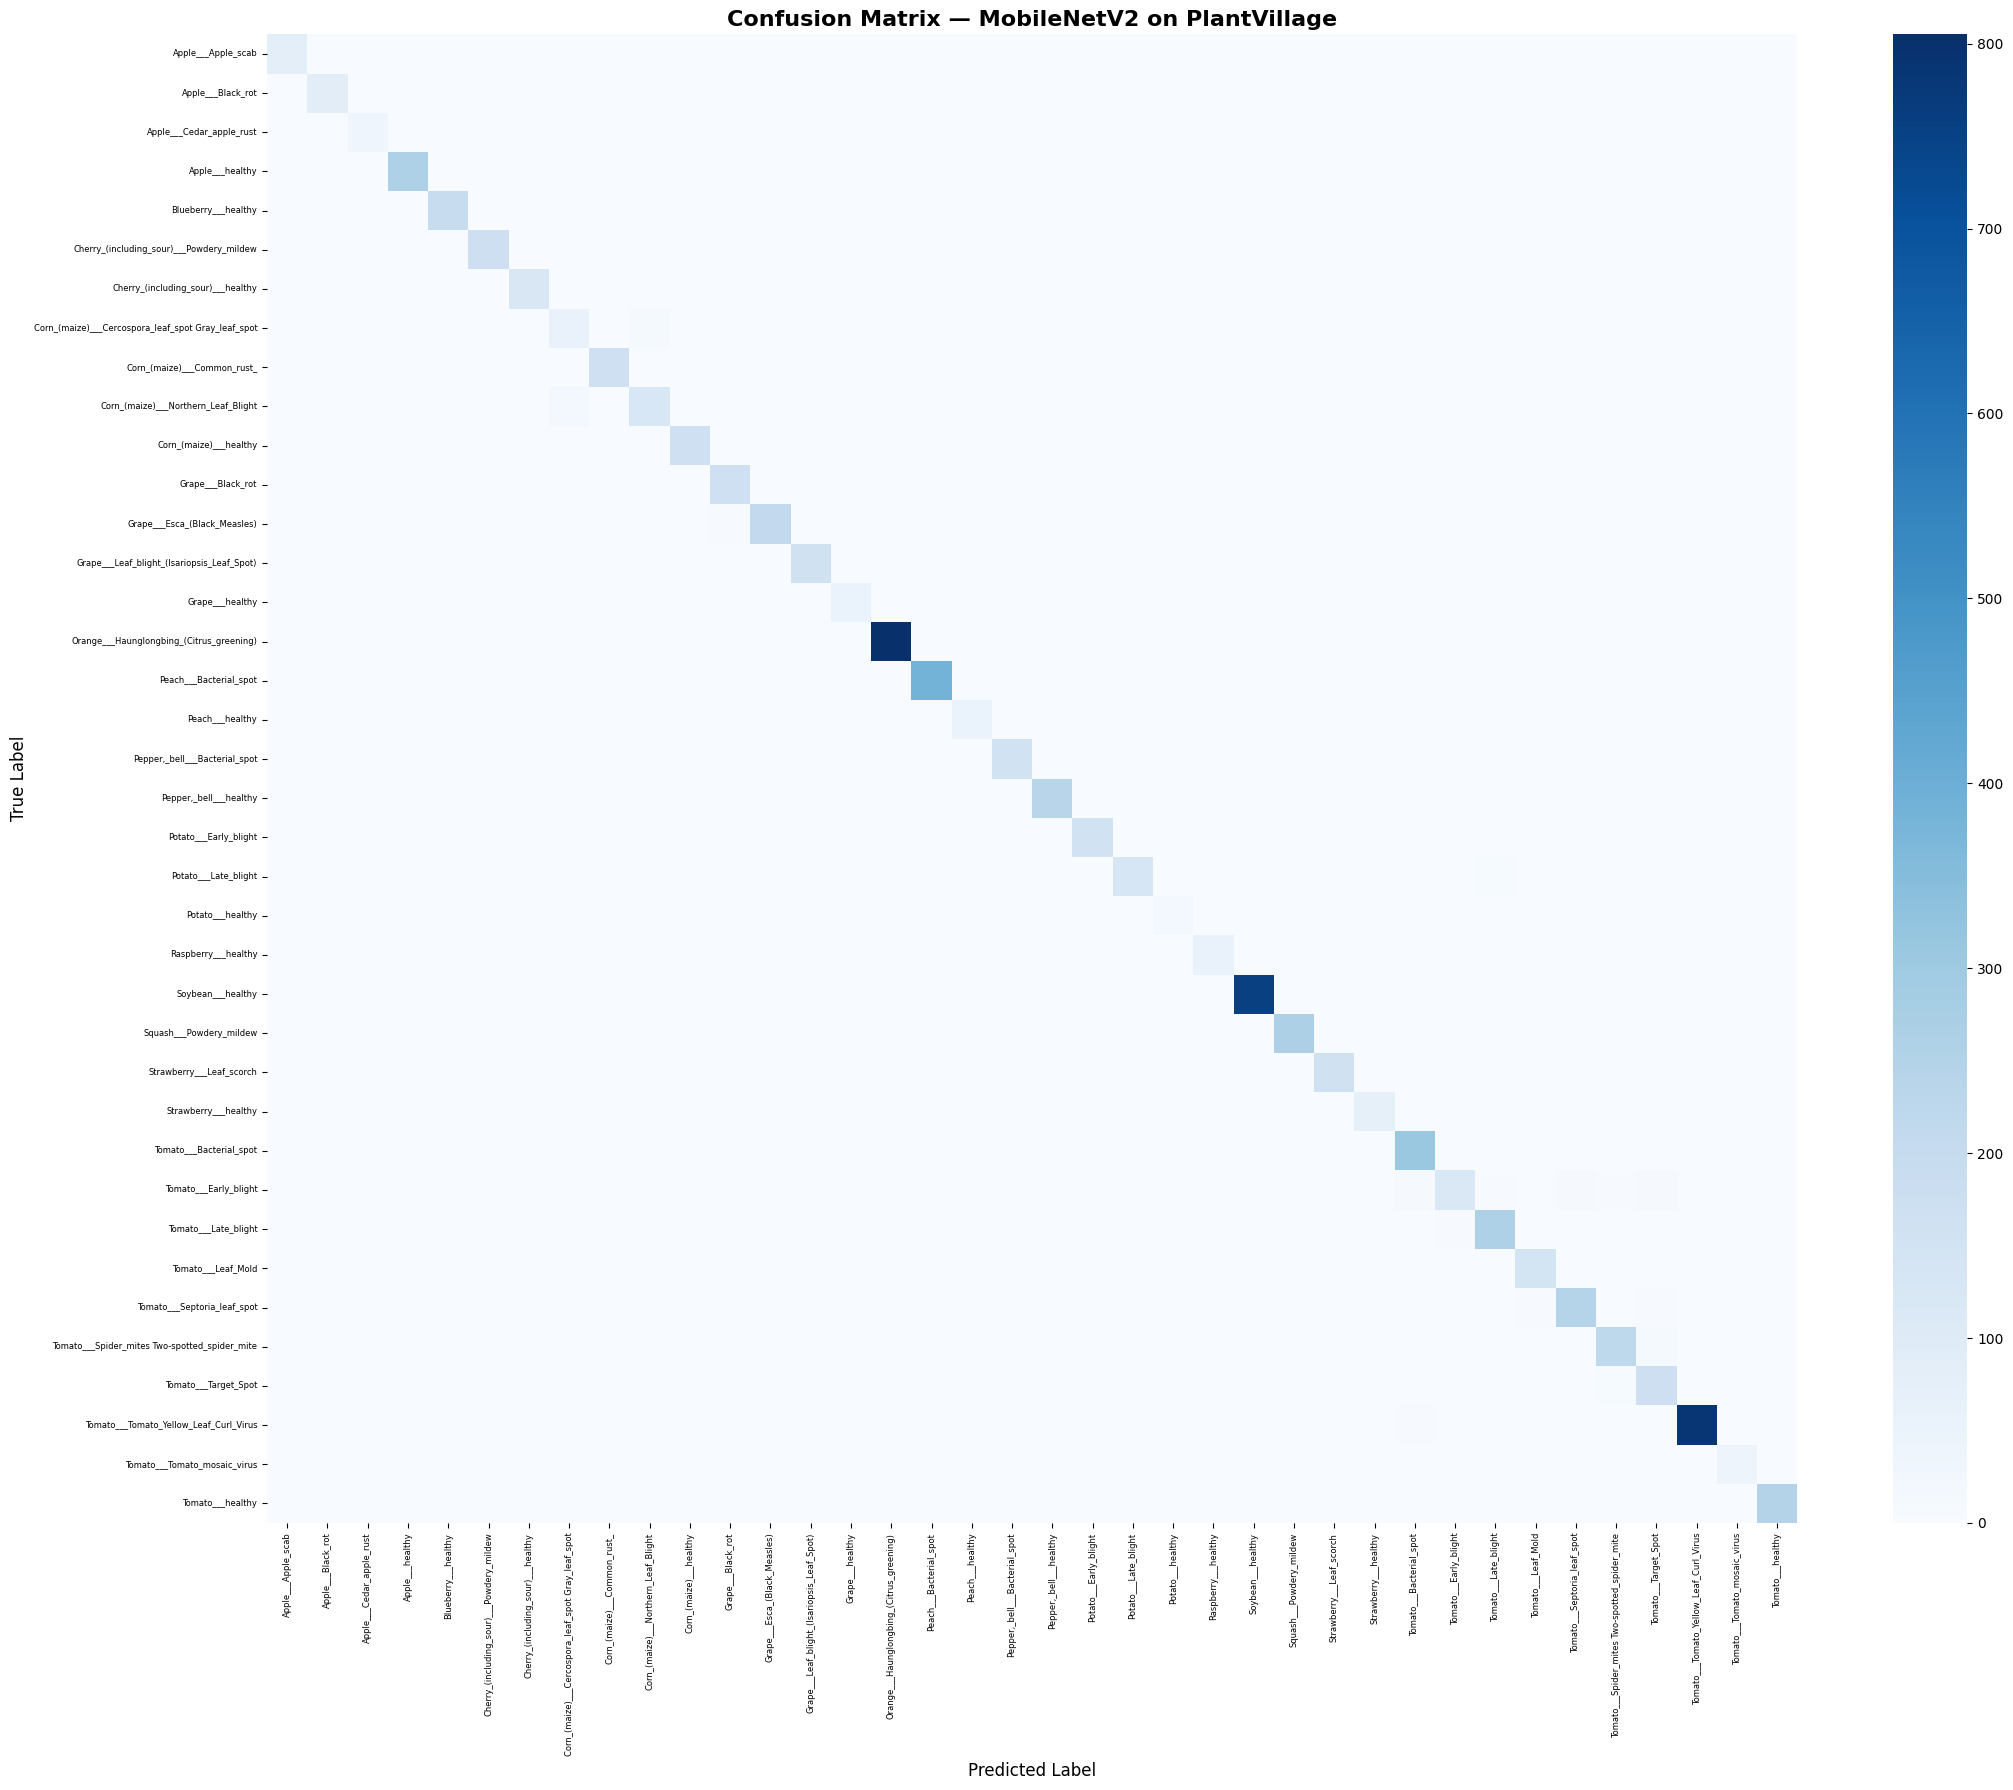

Saved: confusion_matrix.png ✅


In [7]:
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(22, 18))
sns.heatmap(
    cm,
    annot=False,           # too many classes for numbers — use color intensity
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — MobileNetV2 on PlantVillage', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png ✅")

In [8]:
print("\nTop 10 Most Confused Class Pairs:")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
 
misclass_indices = np.dstack(np.unravel_index(
    np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape
))[0][:10]
 
for true_idx, pred_idx in misclass_indices:
    count = cm_no_diag[true_idx][pred_idx]
    if count > 0:
        print(f"  True: {class_names[true_idx]:<45} → Predicted: {class_names[pred_idx]:<45} ({count} times)")


Top 10 Most Confused Class Pairs:
  True: Corn_(maize)___Northern_Leaf_Blight           → Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot (20 times)
  True: Tomato___Spider_mites Two-spotted_spider_mite → Predicted: Tomato___Target_Spot                          (15 times)
  True: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Predicted: Corn_(maize)___Northern_Leaf_Blight           (13 times)
  True: Tomato___Early_blight                         → Predicted: Tomato___Septoria_leaf_spot                   (12 times)
  True: Tomato___Early_blight                         → Predicted: Tomato___Bacterial_spot                       (11 times)
  True: Tomato___Early_blight                         → Predicted: Tomato___Target_Spot                          (10 times)
  True: Tomato___Target_Spot                          → Predicted: Tomato___Spider_mites Two-spotted_spider_mite (9 times)
  True: Potato___Late_blight                          → Predicted: Tomato___Late_blight 